# Logistic Regression with Breast Cancer Dataset

This notebook demonstrates how to use **Logistic Regression**, a fundamental classification algorithm, to predict whether a tumor is malignant or benign using the Breast Cancer Wisconsin dataset.

## What is Logistic Regression?

Logistic Regression is a **supervised learning** algorithm used for **binary classification**.

It models the probability that an input $\mathbf{x}$ belongs to class $y=1$ using the **logistic (sigmoid)** function:

$$
P(y=1 | \mathbf{x}) = \frac{1}{1 + e^{- (\mathbf{w}^T \mathbf{x} + b)}}
$$

The output is a probability between 0 and 1. We classify an observation as class `1` if the predicted probability exceeds a threshold (typically 0.5).

## Step 1: Load and Explore the Data

We use the `load_breast_cancer()` dataset from Scikit-Learn. It includes 30 numeric features extracted from breast mass images.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=31
)

# Normalize (Standardize) features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 3: Split the Data and Train the Model

We split the dataset into training and testing sets, and fit a logistic regression model.

In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


## Step 4: Evaluate the Model

We will evaluate our model using the following metrics:

- **Accuracy**: Proportion of correct predictions
- **Precision**: Proportion of positive predictions that are correct
- **Recall (Sensitivity)**: Proportion of actual positives correctly identified
- **F1 Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: Table showing true vs. predicted labels
- **ROC Curve**: Tradeoff between true positive and false positive rates
- **AUC (Area Under Curve)**: Summary of ROC curve performance

## Step 4: Evaluate the Model

**Metrics Used:**
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC Curve and AUC

In [3]:
from sklearn.metrics import (
    classification_report,
    roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9766081871345029
Precision: 0.981651376146789
Recall: 0.981651376146789
F1 Score: 0.981651376146789

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        62
           1       0.98      0.98      0.98       109

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



### What is a Confusion Matrix?

A **confusion matrix** is a table used to describe the performance of a classification model. For binary classification:

|                 | Predicted Positive | Predicted Negative |
|-----------------|--------------------|--------------------|
| Actual Positive | True Positive (TP) | False Negative (FN)|
| Actual Negative | False Positive (FP)| True Negative (TN) |

- **Accuracy** = (TP + TN) / (TP + TN + FP + FN)  
- **Precision** = TP / (TP + FP)  
- **Recall (Sensitivity)** = TP / (TP + FN)  
- **F1 Score** = 2 * (Precision * Recall) / (Precision + Recall)

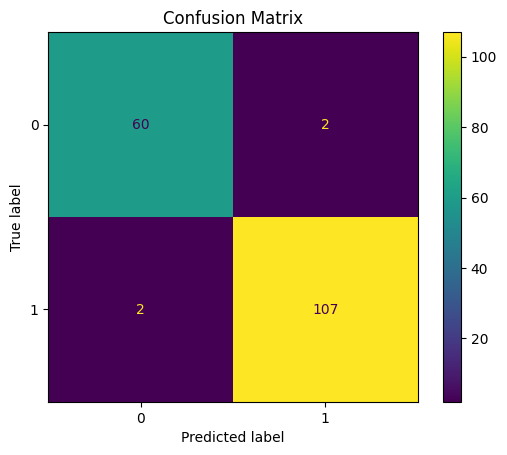

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion Matrix')
plt.show()

### What is an ROC Curve?

An **ROC Curve** (Receiver Operating Characteristic) plots:

- **True Positive Rate (Recall)** on the Y-axis
- **False Positive Rate (1 - Specificity)** on the X-axis

Each point on the curve corresponds to a different classification threshold. A model with perfect classification has a point in the top-left corner.

**AUC (Area Under Curve)** summarizes the ROC curve into a single value between 0 and 1:
- AUC = 1: Perfect classifier
- AUC = 0.5: No better than random guessing

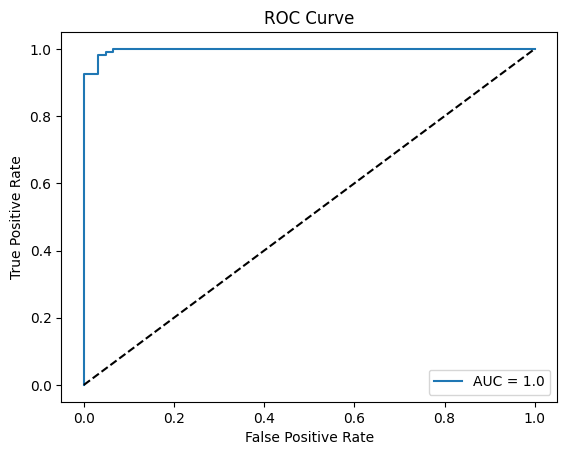

In [5]:
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = ' + str(round(roc_auc, 2)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()